In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import gaussian_kde
from tqdm import tqdm
from scipy.integrate import quad
plt.style.use(['science','notebook'])

colors = ["#1982c4", "black", "#ff595e", "#20b806"]

In [2]:
seeds = np.arange(4)
ntrajs = 2500
nsteps = 2000
traj_noint = np.zeros((nsteps,len(seeds),ntrajs,2))
traj_intx3 =  np.zeros((nsteps,len(seeds),ntrajs,2))
traj_intx3neg =  np.zeros((nsteps,len(seeds),ntrajs,2))
traj_inty3 =  np.zeros((nsteps,len(seeds),ntrajs,2))
traj_inty3neg =  np.zeros((nsteps,len(seeds),ntrajs,2))
dir_noint = "/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_int/pickles_traj"
dirx = "/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_int/pickles_traj_intx"
diry = "/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_int/pickles_traj_inty"
for seed in seeds:
    with open(f"{dir_noint}/seed{seed}_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_temp1.p","rb") as f:
        traj_noint[:,seed] = (
            pickle.load(f)
        )
    with open(f"{dirx}/seed{seed}_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_temp1.p","rb") as f:
        [traj_intx3[:,seed], traj_intx3neg[:,seed]] = (
            pickle.load(f)
        )
    with open(f"{diry}/seed{seed}_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_temp1.p","rb") as f:
        [traj_inty3[:,seed], traj_inty3neg[:,seed]] = (
            pickle.load(f)
        )

traj_noint = traj_noint.reshape((nsteps,len(seeds)*ntrajs,2))
traj_intx3 = traj_intx3.reshape((nsteps,len(seeds)*ntrajs,2))
traj_intx3neg = traj_intx3neg.reshape((nsteps,len(seeds)*ntrajs,2))
traj_inty3 = traj_inty3.reshape((nsteps,len(seeds)*ntrajs,2))
traj_inty3neg = traj_inty3neg.reshape((nsteps,len(seeds)*ntrajs,2))

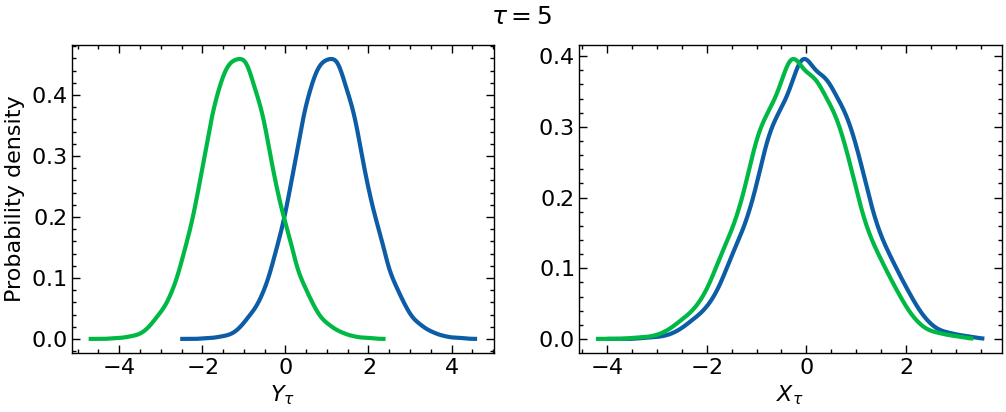

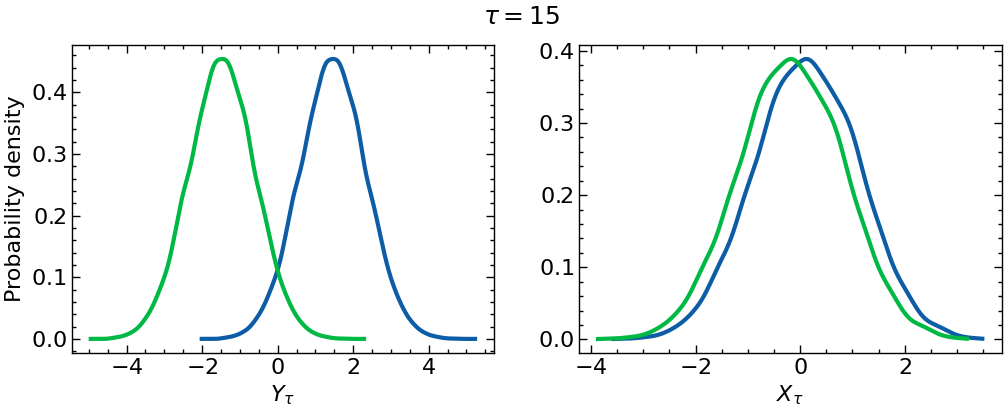

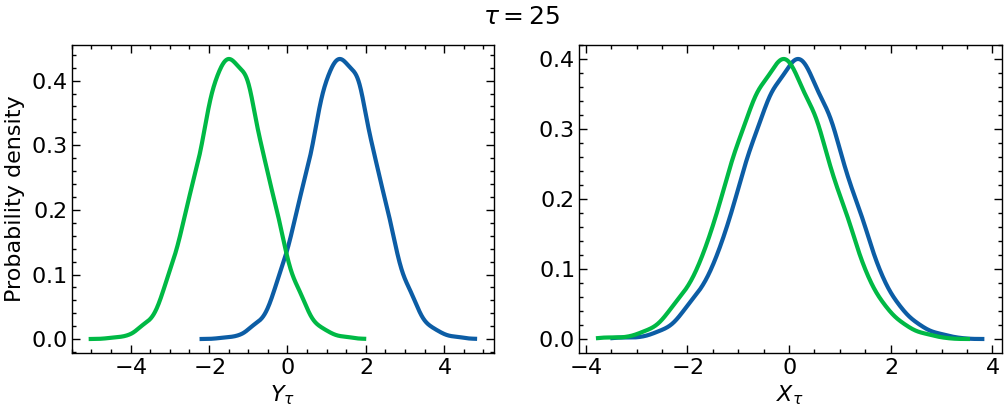

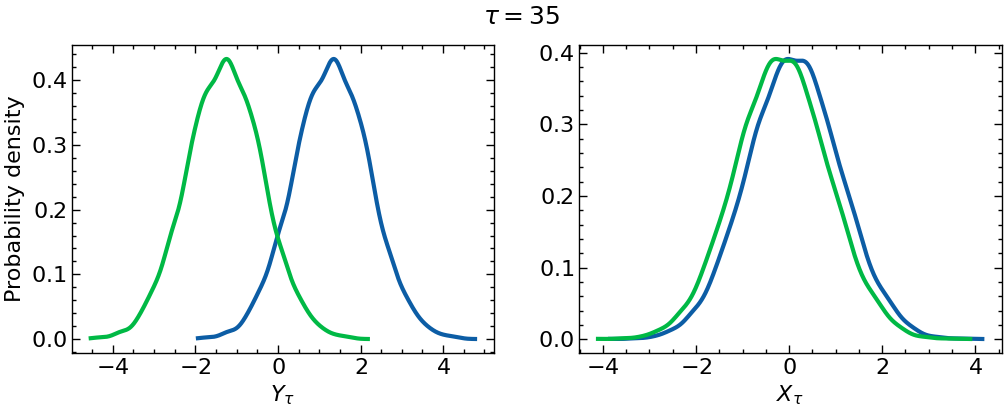

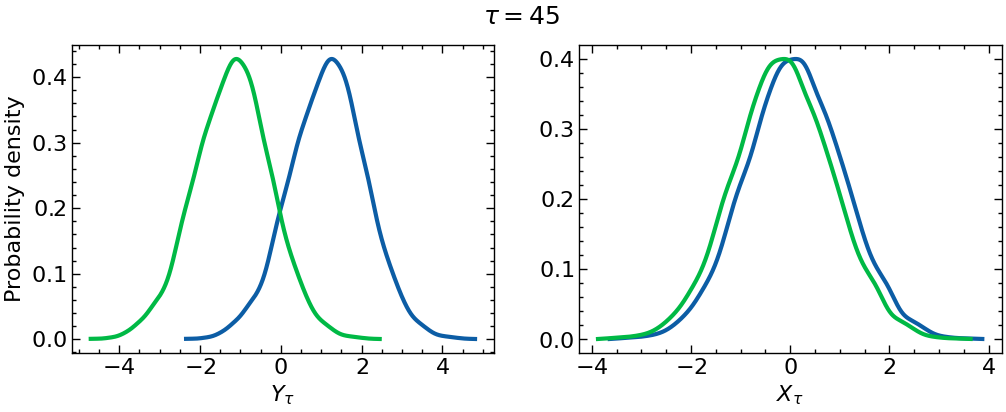

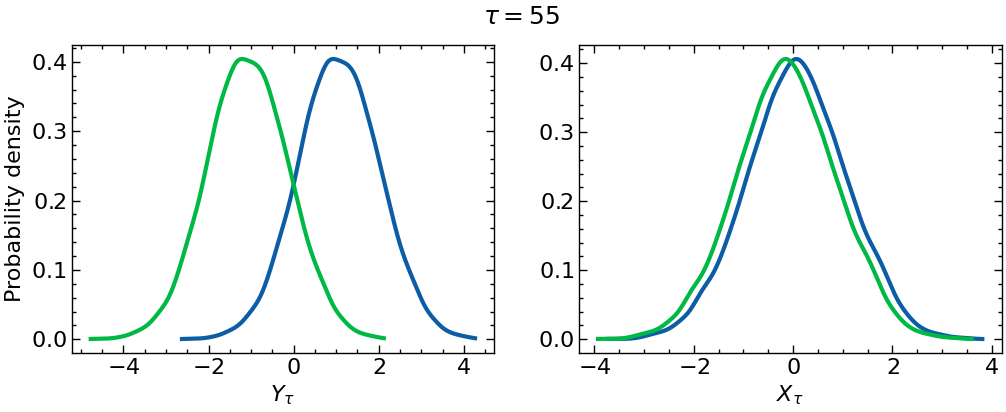

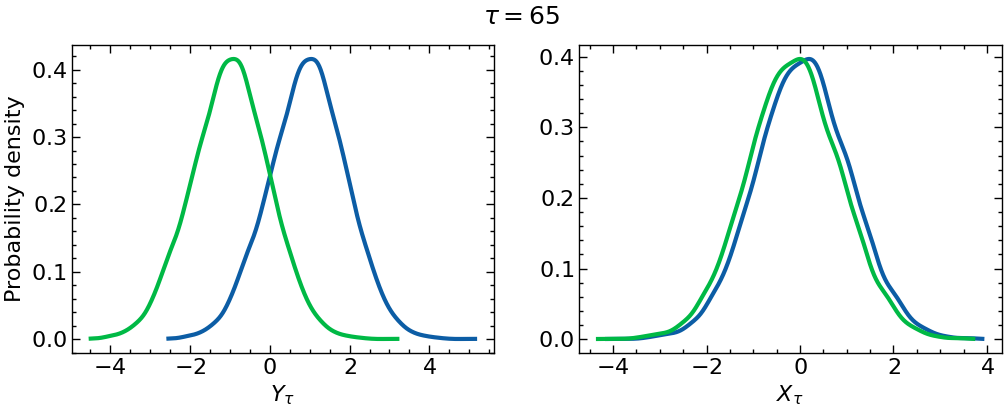

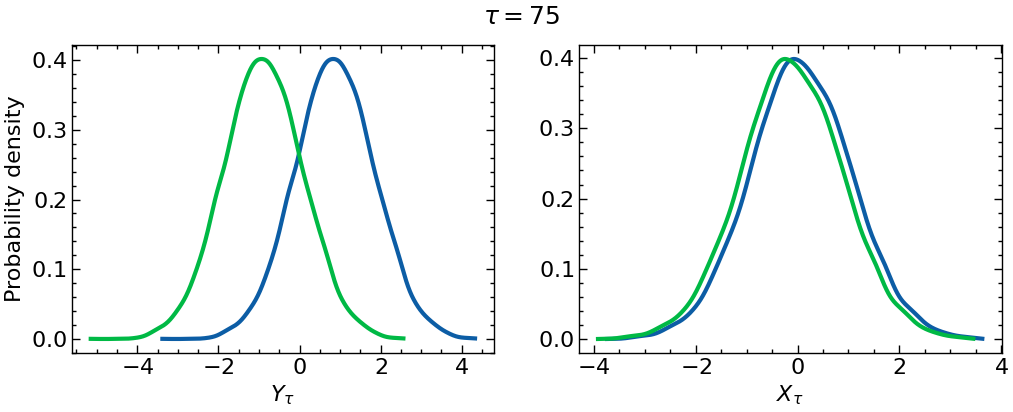

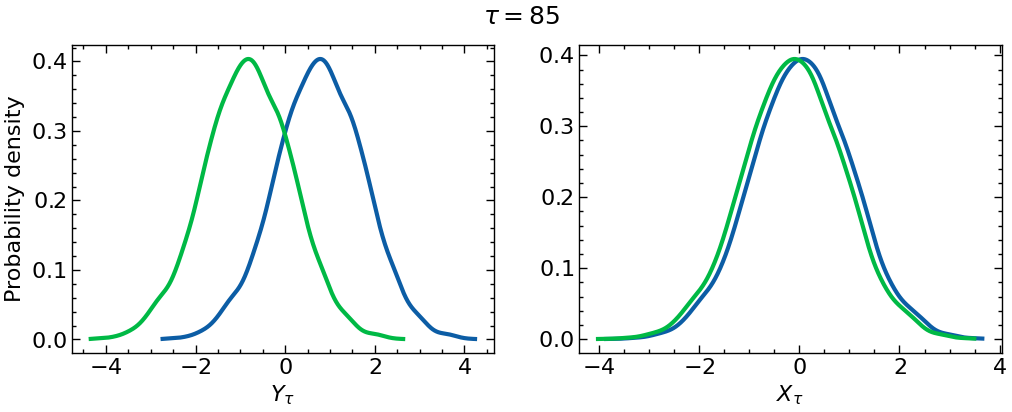

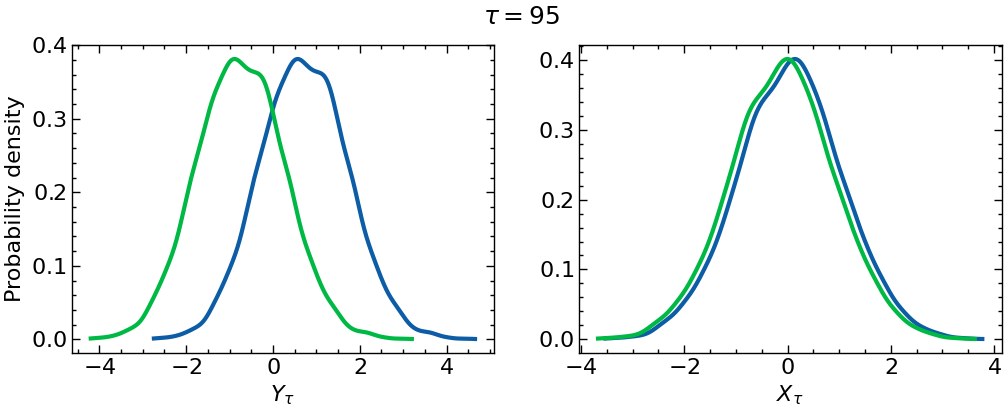

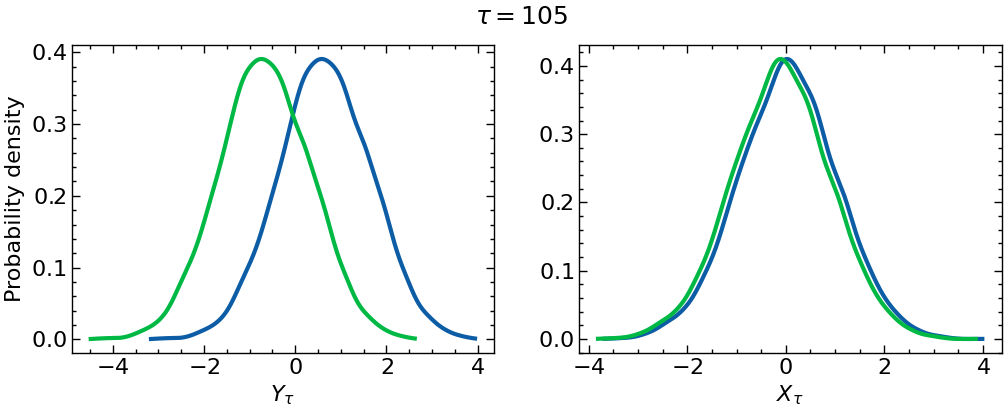

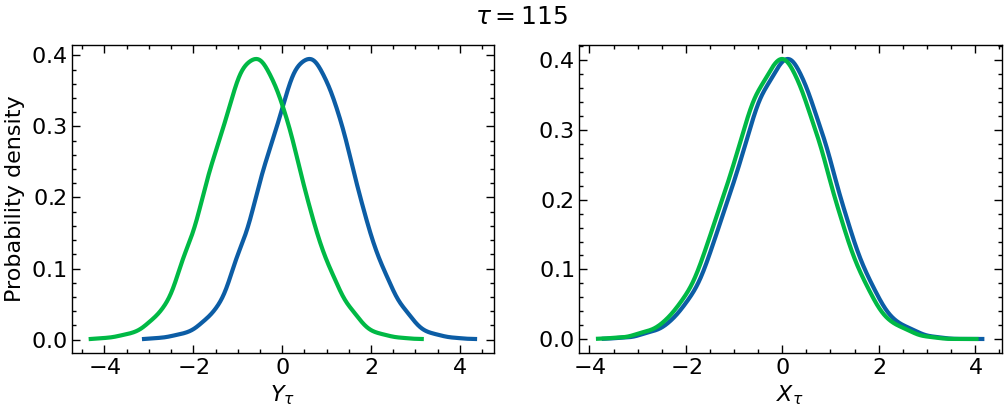

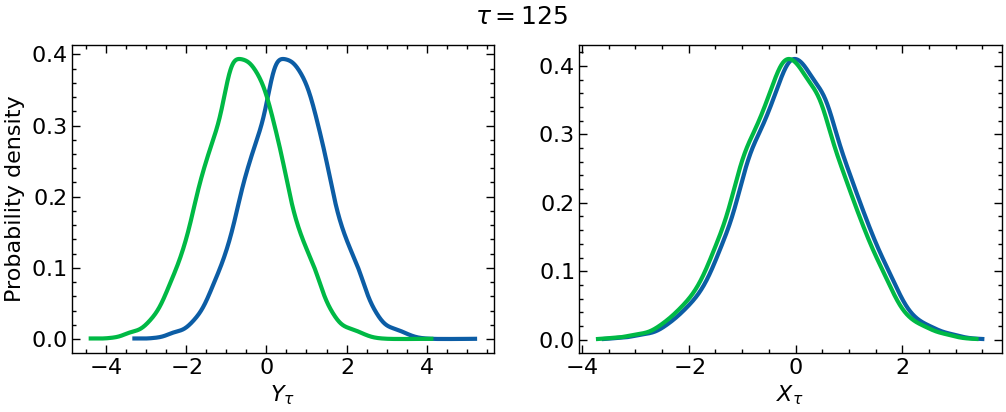

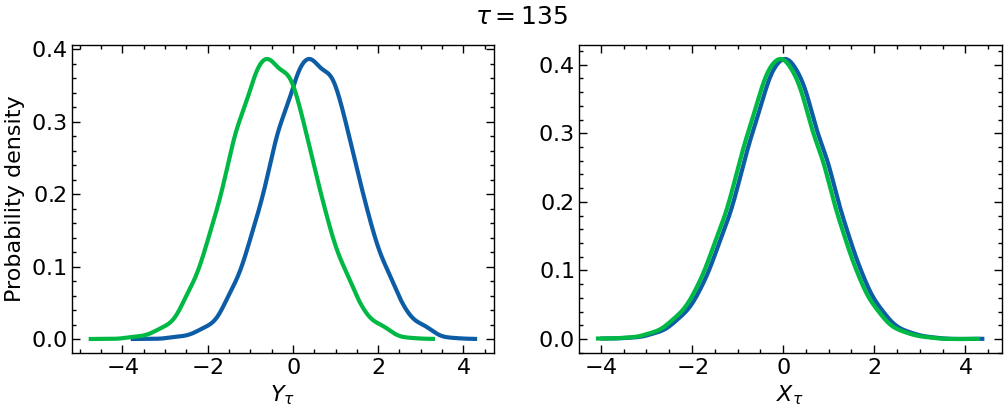

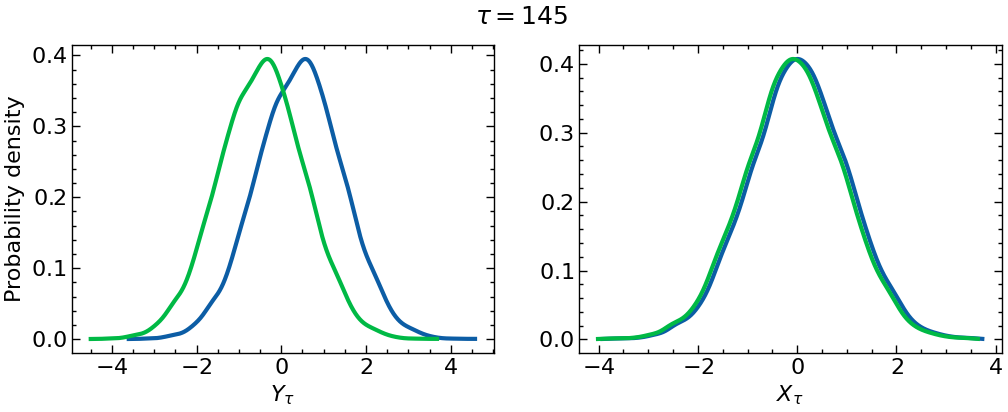

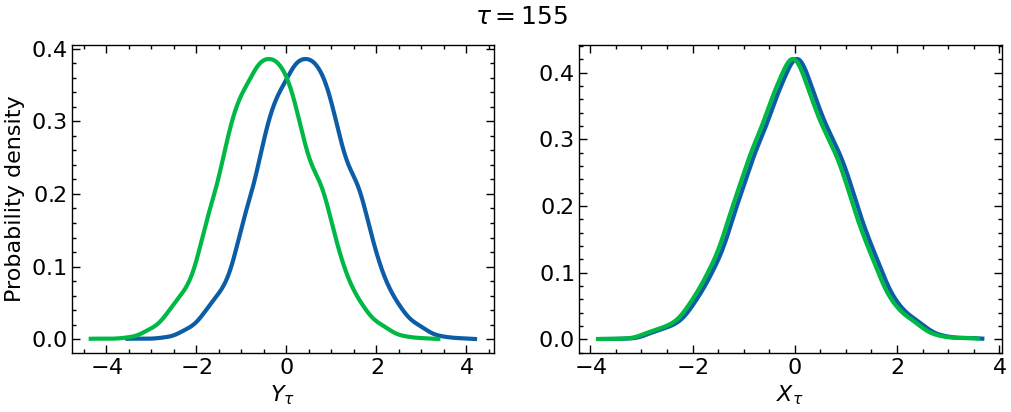

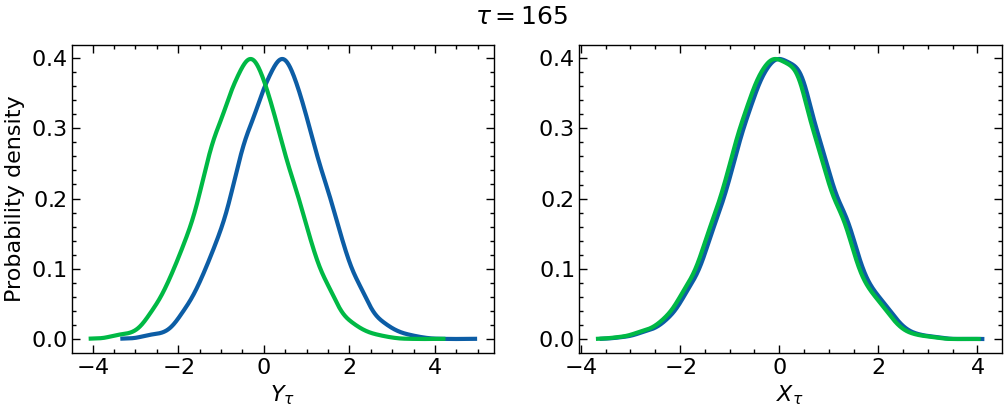

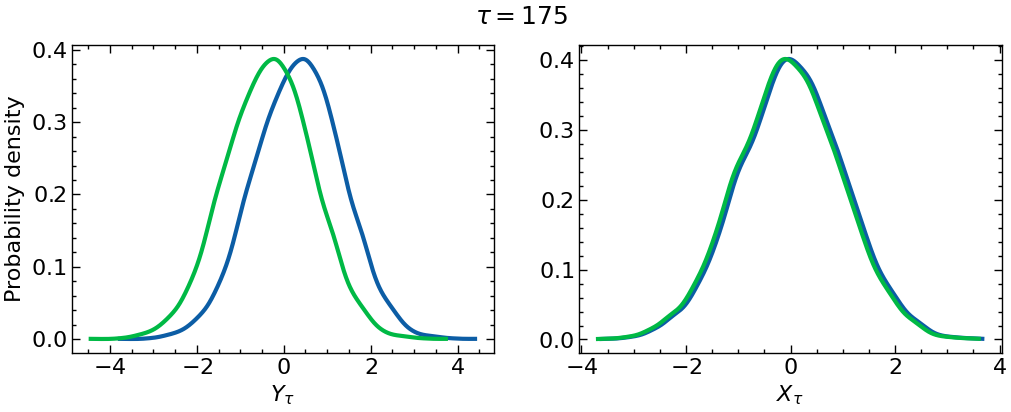

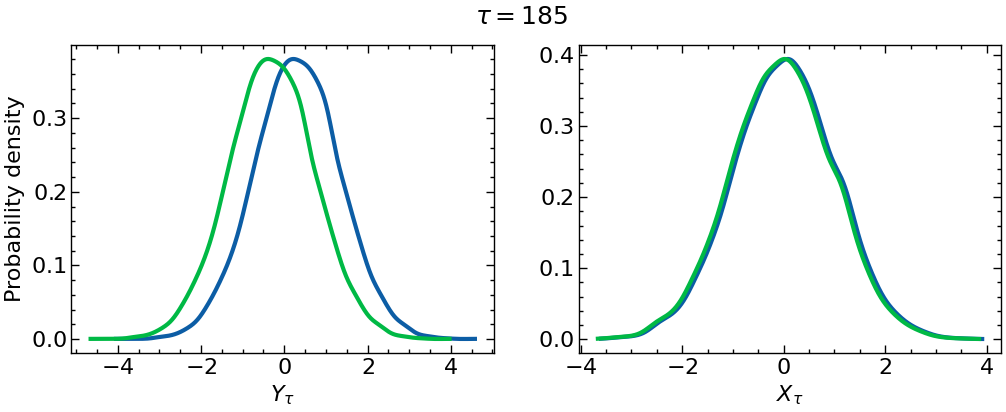

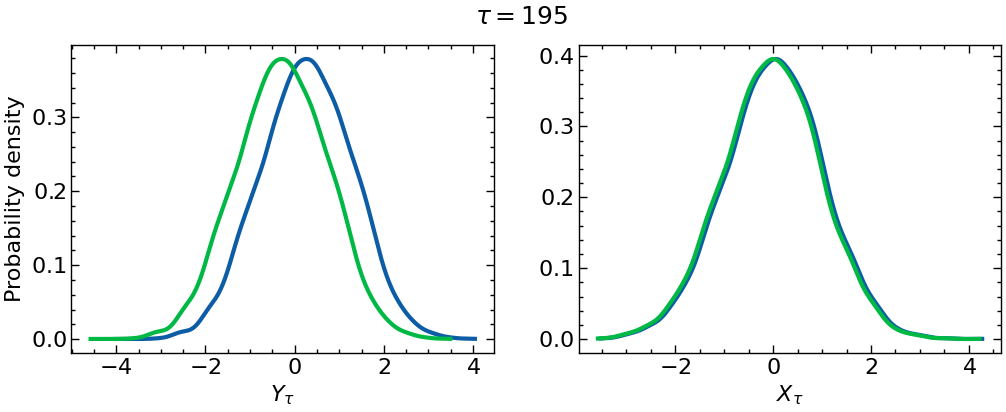

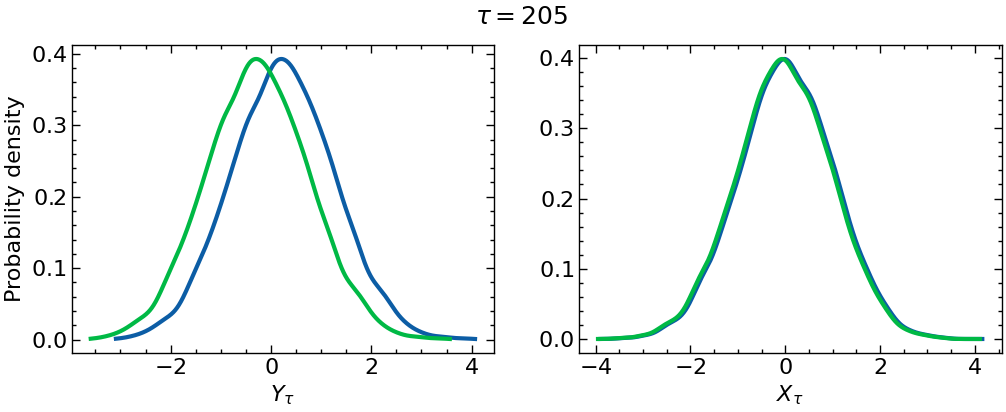

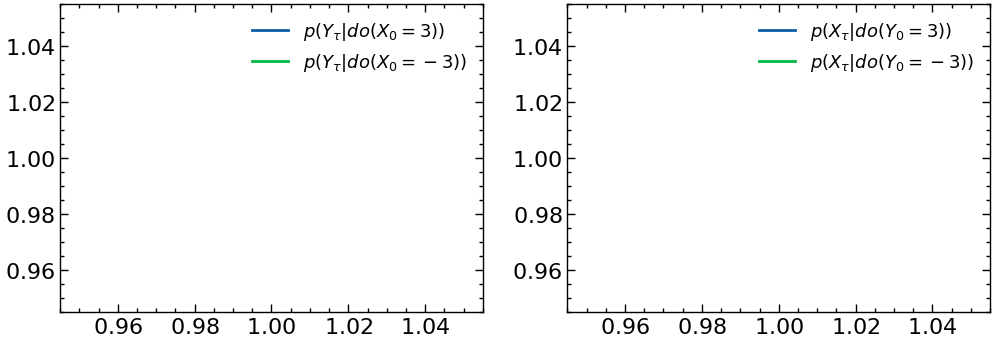

In [3]:
taus = np.arange(5,215,10,dtype=int)
bins = 50
linewidth = 3
alpha = 1

for itau, tau in enumerate(taus):
    fig, ax = plt.subplots(1,2,figsize=(12,4))

    #do(X=3)
    kde = gaussian_kde(traj_intx3[tau,:,1])
    x_range = np.linspace(min(traj_intx3[tau,:,1]), max(traj_intx3[tau,:,1]), 1000)
    ax[0].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(Y_{\\tau}|do(X_0=3))$")
    #do(X=-3)
    kde = gaussian_kde(traj_intx3neg[tau,:,1])
    x_range = np.linspace(min(traj_intx3neg[tau,:,1]), max(traj_intx3neg[tau,:,1]), 1000)
    ax[0].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(Y_{\\tau}|do(X_0=-3))$")

    #do(Y=3)
    kde = gaussian_kde(traj_inty3[tau,:,0])
    x_range = np.linspace(min(traj_inty3[tau,:,0]), max(traj_inty3[tau,:,0]), 1000)
    ax[1].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(X_{\\tau}|do(Y_0=3))$")
    #do(Y=-3)
    kde = gaussian_kde(traj_inty3neg[tau,:,0])
    x_range = np.linspace(min(traj_inty3neg[tau,:,0]), max(traj_inty3neg[tau,:,0]), 1000)
    ax[1].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(X_{\\tau}|do(Y_0=-3))$")
    
    ax[0].set(xlabel="$Y_{\\tau}$", ylabel="Probability density")
    ax[1].set(xlabel="$X_{\\tau}$")
    #ax[0].legend(fontsize=13)
    #ax[1].legend(fontsize=13)
    plt.suptitle(f"$\\tau = {tau}$", fontsize=18)
    plt.savefig(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_int/figures/tau{tau}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

# only to have legends
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(1,1, label="$p(Y_{\\tau}|do(X_0=3))$")
ax[0].plot(1,1, label="$p(Y_{\\tau}|do(X_0=-3))$")
ax[1].plot(1,1, label="$p(X_{\\tau}|do(Y_0=3))$")
ax[1].plot(1,1, label="$p(X_{\\tau}|do(Y_0=-3))$")
ax[0].legend(fontsize=13)
ax[1].legend(fontsize=13)
plt.savefig(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_int/figures/legends.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Compute KL divergences

In [8]:
def estimate_pdf(data, points):
        kde = gaussian_kde(data)
        return kde(points)

# compute KL divergence
def kl_divergence(X, Y, num_points=1000):
    # Generate a range of values to estimate the PDFs
    min_value = min(np.min(X), np.min(Y))
    max_value = max(np.max(X), np.max(Y))
    points = np.linspace(min_value, max_value, num_points)

    # Estimate PDFs for both X and Y
    pdf_X = estimate_pdf(X, points)
    pdf_Y = estimate_pdf(Y, points)
    
    # Add a small epsilon to avoid division by zero or log(0)
    epsilon = 1e-10
    pdf_X = np.clip(pdf_X, epsilon, None)
    pdf_Y = np.clip(pdf_Y, epsilon, None)
    
    # Step 3: Compute KL divergence
    kl_div = np.sum(pdf_X * np.log(pdf_X / pdf_Y)) * (max_value - min_value) / num_points
    return kl_div

In [16]:
taus = np.arange(5,215,10,dtype=int)
bins = 50
linewidth = 3
alpha = 1

KLs_x3_x3neg = []
KLs_y3_y3neg = []

for itau, tau in tqdm(enumerate(taus)):
    fig, ax = plt.subplots(1,2,figsize=(12,4))

    # KL[p(Y|do(X=3)) || p(Y|do(X=-3))]
    KLs_x3_x3neg.append(kl_divergence(traj_intx3[tau,:,1],traj_intx3neg[tau,:,1]))

    # KL[p(X|do(Y=3)) || p(X|do(Y=-3))]
    KLs_y3_y3neg.append(kl_divergence(traj_inty3[tau,:,1],traj_inty3neg[tau,:,1]))

plt.figure(figsize=(7,5))
# do(X)
plt.plot(taus, KLs_x3_x3neg,  '-',  color=colors[0], alpha=alpha, linewidth=linewidth, label="KL$[p(Y_\\tau|do(X_0=3)) \| p(Y_\\tau|do(X_0=-3))]$")
# do(Y)
plt.plot(taus, KLs_y3_y3neg,  '-',  color=colors[1], alpha=alpha, linewidth=linewidth, label="KL$[p(X_\\tau|do(Y_0=3)) \| p(X_\\tau|do(Y_0=-3))]$")

plt.xlabel("Time lag $\\tau$")
plt.ylabel("Kullback-Leibler divergence")
plt.legend()
#plt.suptitle(f"$\\tau = {tau*10}$", fontsize=18) # multiply by 10 to have same units used in panels E and F
plt.savefig(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_int/figures/KL.pdf", dpi=300, bbox_inches="tight")
plt.show()

1it [00:01,  1.98s/it]